# 💳 Fraud Detection Project (Simple Version)

We are teaching a computer to guess if a money transaction is **FRAUD** or **NOT FRAUD**.

Think of it like this: we show the computer thousands of old transactions where
we already know which ones were fraud. The computer learns the "pattern" of
fraud. Then we test it on new transactions it has never seen, to see if it
guesses correctly.

**Steps we will follow:**
1. Load the data
2. Look at the data (understand it)
3. Clean the data (fix problems)
4. Look at pictures/charts of the data (EDA)
5. Create helpful new columns (feature engineering)
6. Split data into "practice" and "test" sets
7. Prepare the data for the computer
8. Try many different models
9. Pick the best one
10. Save it and build a simple app

⚠️ Run every cell from top to bottom, one time each.


dataset:
https://www.kaggle.com/datasets/amanalisiddiqui/fraud-detection-dataset


## Step 1: Get Our Tools Ready

In [ ]:
!pip install scikit-learn==1.9.0 -q

In [ ]:
import sklearn
print(sklearn.__version__)

1.9.0


In [ ]:
# We need some helper tools (called "libraries") before we start.
# Think of these like a toolbox — each tool does a different job.

import pandas as pd      # helps us work with tables of data (like Excel)
import numpy as np       # helps us do math with numbers

import matplotlib.pyplot as plt   # helps us draw charts
import seaborn as sns             # makes charts look nicer

# Tools to split data and prepare it for the model
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Different "brains" (models) we will try
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

# Tools to check how good our model is
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, classification_report, ConfusionMatrixDisplay
)

import joblib  # helps us save our trained model to a file
import warnings
warnings.filterwarnings("ignore")  # hide small warning messages we don't need to see

sns.set_style("whitegrid")  # make our charts look clean
print("All tools are ready!")


All tools are ready!


## Step 2: Load the Data

We have a big file full of money transactions. Some are real, some are fraud.
The file is HUGE (millions of rows), so we will only grab a smaller chunk
(200,000 rows) to make things faster. We make sure to keep the same amount
of "fraud" and "not fraud" examples in our smaller chunk.


In [ ]:
# Open the big file and load it into a table called df_full
df_full = pd.read_csv("/content/AIML Dataset.csv")
print("Full file size:", df_full.shape)

# Check if any rows are missing the answer (isFraud). We can't use those rows.
print("Rows with missing answer:", df_full['isFraud'].isnull().sum())

# Remove any rows that don't have an answer
df_full = df_full.dropna(subset=['isFraud']).reset_index(drop=True)

# Grab a smaller sample of 200,000 rows, but keep the same fraud/not-fraud ratio
df, _ = train_test_split(
    df_full,
    train_size=200_000,
    stratify=df_full['isFraud'],   # keeps fraud ratio the same in our sample
    random_state=42                # makes sure we get the same sample every time
)
df = df.reset_index(drop=True)

del df_full  # we don't need the huge file anymore, so free up memory

print("Our smaller sample size:", df.shape)
print(df['isFraud'].value_counts(normalize=True))
df.head()


Full file size: (614230, 11)
Rows with missing answer: 1
Our smaller sample size: (200000, 11)
isFraud
0.0    0.999395
1.0    0.000605
Name: proportion, dtype: float64


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,19,CASH_OUT,110190.91,C1284712429,20693.00,0.00,C1613122851,235511.20,345702.11,0.0,0.0
1,33,PAYMENT,1958.42,C2018654033,0.00,0.00,M331840299,0.00,0.00,0.0,0.0
2,17,PAYMENT,23118.62,C1427333432,0.00,0.00,M1298975249,0.00,0.00,0.0,0.0
3,15,CASH_IN,48271.35,C1686460589,5188138.36,5236409.71,C2058178555,833298.24,785026.88,0.0,0.0
4,20,CASH_IN,179943.81,C896903972,5002402.89,5182346.71,C2107266392,1528965.93,1349022.12,0.0,0.0


## Step 3: Look at the Data

Before we do anything else, let's just LOOK at what we have.


In [ ]:
df.head()   # shows the first 5 rows, like peeking at the top of a list

In [ ]:
df.tail()

In [ ]:
df.info()   # tells us the column names, types, and how many rows have data


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            200000 non-null  int64  
 1   type            200000 non-null  object 
 2   amount          200000 non-null  float64
 3   nameOrig        200000 non-null  object 
 4   oldbalanceOrg   200000 non-null  float64
 5   newbalanceOrig  200000 non-null  float64
 6   nameDest        200000 non-null  object 
 7   oldbalanceDest  200000 non-null  float64
 8   newbalanceDest  200000 non-null  float64
 9   isFraud         200000 non-null  float64
 10  isFlaggedFraud  200000 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 16.8+ MB


In [ ]:
df.describe()   # gives min, max, average for number columns

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,200000.000000,2.000000e+05,2.000000e+05,2.000000e+05,2.000000e+05,2.000000e+05,200000.000000,200000.0
mean,16.021515,1.615339e+05,8.869809e+05,9.066853e+05,9.710799e+05,1.135348e+06,0.000605,0.0
std,6.086529,2.706650e+05,2.956530e+06,2.993296e+06,2.306586e+06,2.464194e+06,0.024589,0.0
min,1.000000,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
25%,12.000000,1.240853e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
50%,16.000000,7.582746e+04,1.747650e+04,0.000000e+00,1.145347e+05,2.086732e+05,0.000000,0.0
75%,19.000000,2.153523e+05,1.546462e+05,1.940684e+05,8.972287e+05,1.177175e+06,0.000000,0.0
max,34.000000,1.000000e+07,3.844183e+07,3.856340e+07,4.148270e+07,4.138365e+07,1.000000,0.0


In [ ]:
df.columns   # lists all column names


Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

**What kind of columns do we have?**
- **Numbers:** step, amount, oldbalanceOrg, newbalanceOrig, oldbalanceDest, newbalanceDest
- **Words/categories:** type (like TRANSFER, PAYMENT, etc.)
- **ID columns (just names, not useful for predicting):** nameOrig, nameDest
- **The answer we want to predict:** isFraud
- **A column we're not sure about yet:** isFlaggedFraud (we'll check it next)


## Step 4: Check for Problems in the Data

Just like checking your homework for mistakes, we check the data for:
- missing pieces
- copies (duplicates)
- weird/impossible numbers (like negative money)


In [ ]:
# Are any boxes empty (missing values)?
print("Missing values:\n", df.isnull().sum())

# Are there any exact copy rows?
print("\nDuplicate rows:", df.duplicated().sum())

# How many different values are in each column?
print("\nUnique values:\n", df.nunique())


Missing values:
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Duplicate rows: 0

Unique values:
 step                  34
type                   5
amount            198524
nameOrig          199992
oldbalanceOrg     103670
newbalanceOrig     90733
nameDest          111214
oldbalanceDest    116396
newbalanceDest     98016
isFraud                2
isFlaggedFraud         1
dtype: int64


In [ ]:
# Money amounts should never be negative — let's check
print("Negative amount:", (df['amount'] < 0).sum())
print("Negative oldbalanceOrg:", (df['oldbalanceOrg'] < 0).sum())
print("Negative newbalanceOrig:", (df['newbalanceOrig'] < 0).sum())
print("Negative oldbalanceDest:", (df['oldbalanceDest'] < 0).sum())
print("Negative newbalanceDest:", (df['newbalanceDest'] < 0).sum())

# What types of transactions do we have?
print("\nTransaction types:\n", df['type'].value_counts())


Negative amount: 0
Negative oldbalanceOrg: 0
Negative newbalanceOrig: 0
Negative oldbalanceDest: 0
Negative newbalanceDest: 0

Transaction types:
 type
CASH_OUT    71106
PAYMENT     67757
CASH_IN     43311
TRANSFER    16321
DEBIT        1505
Name: count, dtype: int64


In [ ]:
# Does the column 'isFlaggedFraud' actually match real fraud?
# If it doesn't help us tell fraud apart, we won't use it.
print(pd.crosstab(df['isFlaggedFraud'], df['isFraud']))


isFraud            0.0  1.0
isFlaggedFraud             
0.0             199879  121


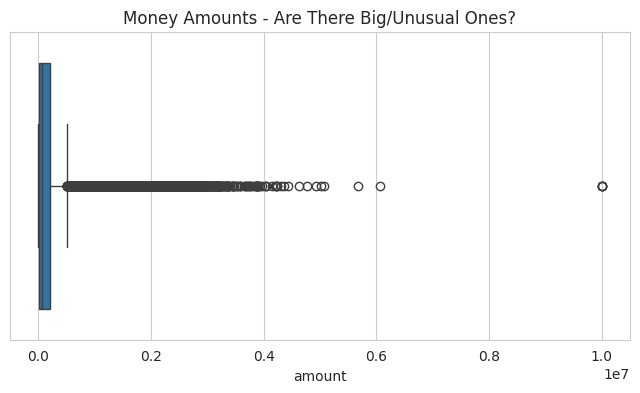

count    2.000000e+05
mean     1.615339e+05
std      2.706650e+05
min      1.000000e-01
25%      1.240853e+04
50%      7.582746e+04
75%      2.153523e+05
max      1.000000e+07
Name: amount, dtype: float64


In [ ]:
# Let's look at how spread out the 'amount' column is (any super big values?)
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['amount'])
plt.title("Money Amounts - Are There Big/Unusual Ones?")
plt.show()

print(df['amount'].describe())


**What we decided:**
- No negative money found — good, no fixing needed there.
- `isFlaggedFraud` barely matches real fraud, so we will **not use it**.
- `nameOrig` and `nameDest` are just ID names, not helpful for predicting, so we will **drop them**.
- Big amount values are normal (real big transactions happen) — we keep them, they are not mistakes.


## Step 5: Look at Charts (EDA = Exploring the Data)

Pictures help us understand data faster than just numbers.


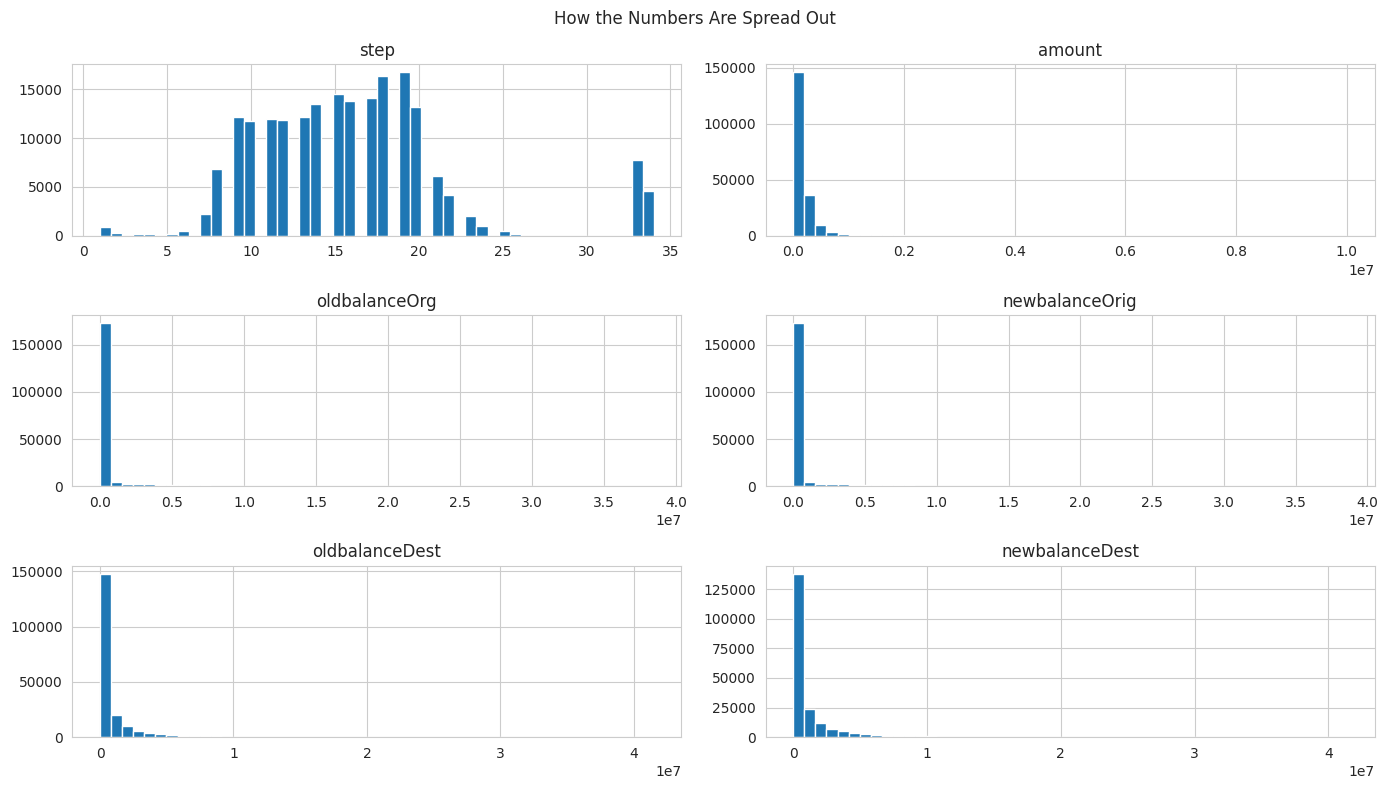

In [ ]:
# Draw a histogram (bar chart of how often values happen) for each number column
num_cols = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

df[num_cols].hist(figsize=(14, 8), bins=50)
plt.suptitle("How the Numbers Are Spread Out")
plt.tight_layout()
plt.show()


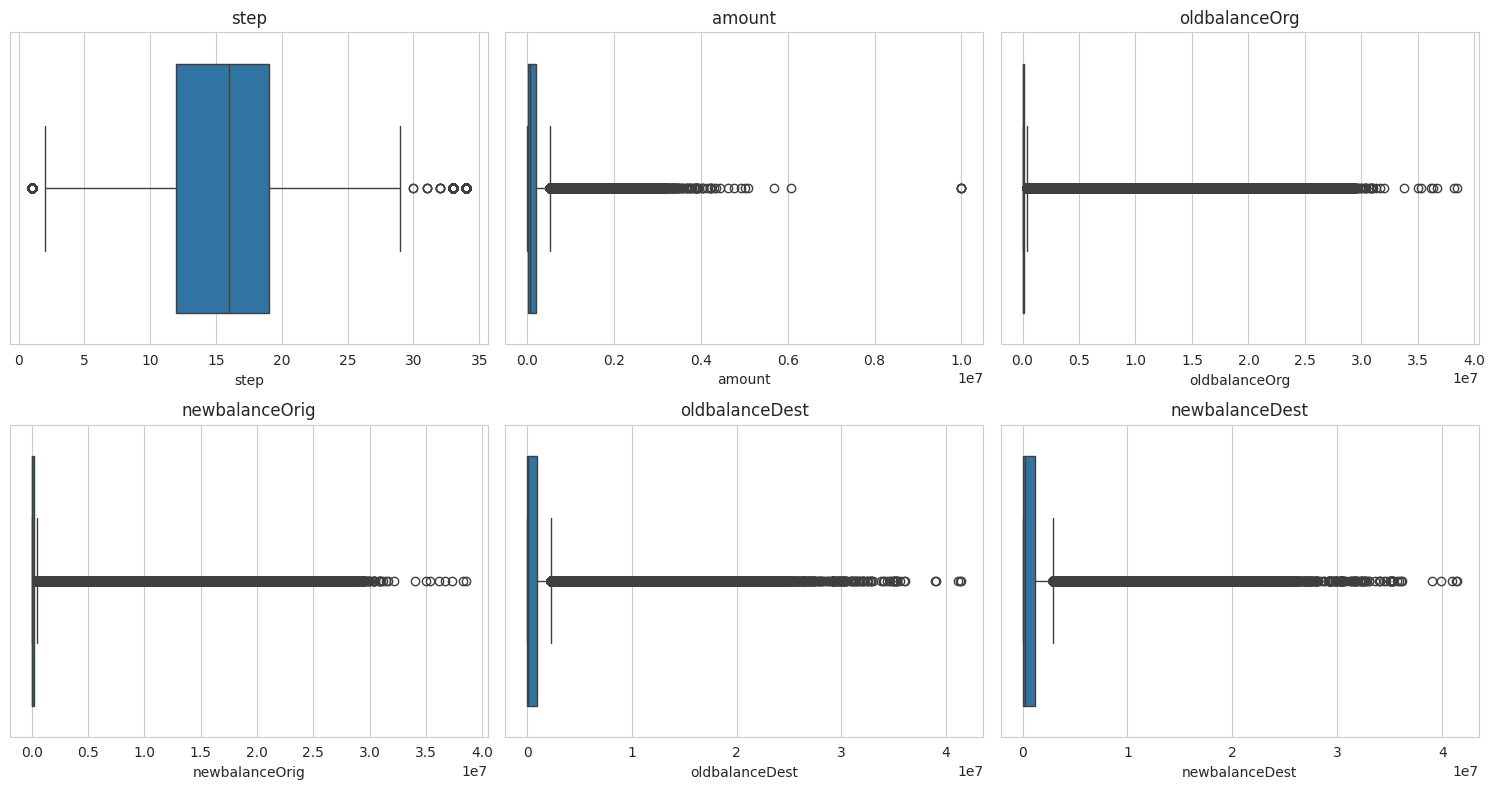

In [ ]:
# Boxplots show us the "normal range" and any unusual points for each column
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


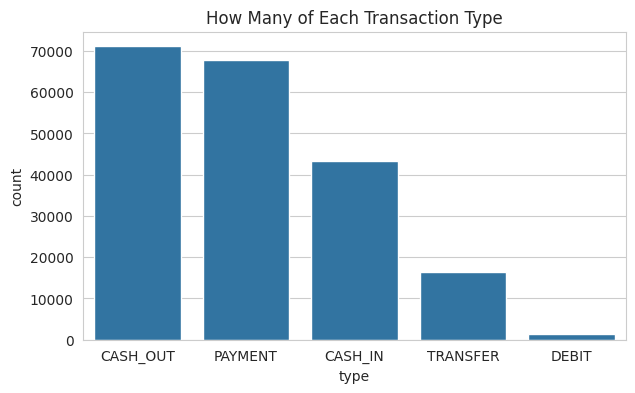

type
CASH_OUT    0.355530
PAYMENT     0.338785
CASH_IN     0.216555
TRANSFER    0.081605
DEBIT       0.007525
Name: proportion, dtype: float64


In [ ]:
# How many transactions of each TYPE do we have?
plt.figure(figsize=(7, 4))
sns.countplot(x='type', data=df, order=df['type'].value_counts().index)
plt.title("How Many of Each Transaction Type")
plt.show()

print(df['type'].value_counts(normalize=True))


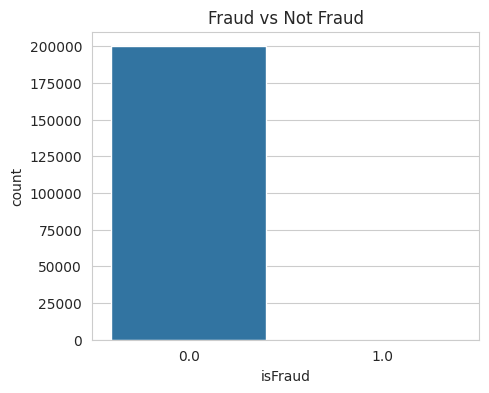

isFraud
0.0    199879
1.0       121
Name: count, dtype: int64
isFraud
0.0    0.999395
1.0    0.000605
Name: proportion, dtype: float64


In [ ]:
# How many fraud vs not-fraud transactions do we have?
plt.figure(figsize=(5, 4))
sns.countplot(x='isFraud', data=df)
plt.title("Fraud vs Not Fraud")
plt.show()

print(df['isFraud'].value_counts())
print(df['isFraud'].value_counts(normalize=True))


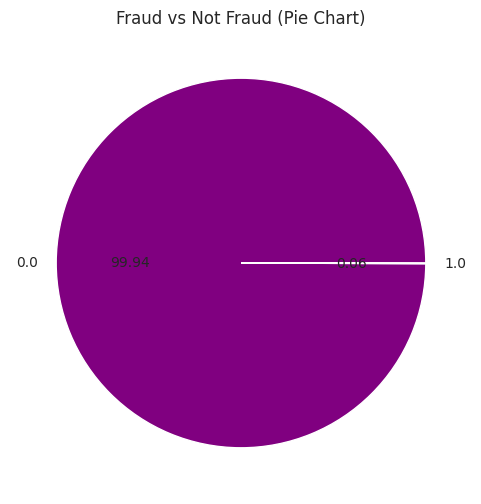

In [ ]:
# A pie chart makes the imbalance easy to see
df['isFraud'].value_counts().plot(
    kind='pie', autopct='%.2f', figsize=(6, 6), colors=['purple', 'orange']
)
plt.title('Fraud vs Not Fraud (Pie Chart)')
plt.ylabel("")
plt.show()


**What we learned:**
Fraud is VERY rare — only about 0.1 out of every 100 transactions is fraud!
This is important: if our model just guessed "not fraud" every single time,
it would be right 99.9% of the time — but totally useless! So we can't just
look at "how often is it right" (accuracy). We need smarter ways to check
if our model is actually good at catching fraud.


## Step 6: Compare Fraud vs Not-Fraud

Now let's see WHAT MAKES fraud different from normal transactions.


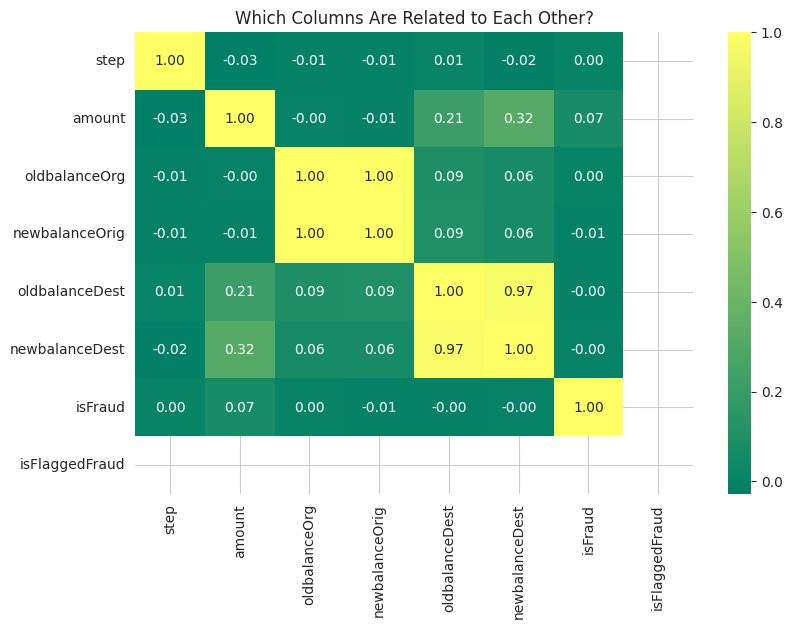

In [ ]:
# A heatmap shows which number columns move together
plt.figure(figsize=(9, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='summer', fmt=".2f")
plt.title("Which Columns Are Related to Each Other?")
plt.show()


          total_transactions  fraud_count  fraud_rate
type                                                 
CASH_IN                43311          0.0    0.000000
CASH_OUT               71106         61.0    0.000858
DEBIT                   1505          0.0    0.000000
PAYMENT                67757          0.0    0.000000
TRANSFER               16321         60.0    0.003676


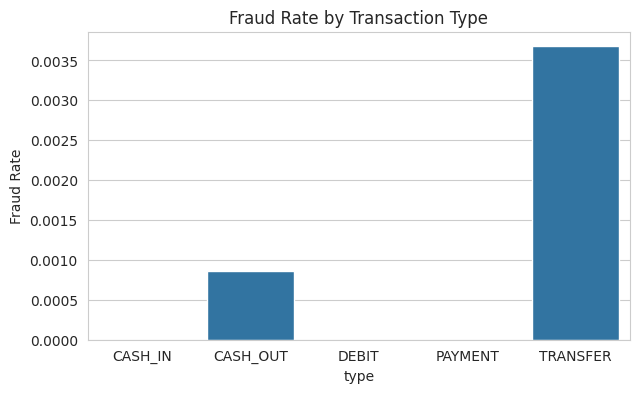

In [ ]:
# Which transaction TYPE has the most fraud?
fraud_by_type = df.groupby('type')['isFraud'].agg(['count', 'sum', 'mean'])
fraud_by_type.columns = ['total_transactions', 'fraud_count', 'fraud_rate']
print(fraud_by_type)

plt.figure(figsize=(7, 4))
sns.barplot(x=fraud_by_type.index, y='fraud_rate', data=fraud_by_type.reset_index())
plt.title("Fraud Rate by Transaction Type")
plt.ylabel("Fraud Rate")
plt.show()


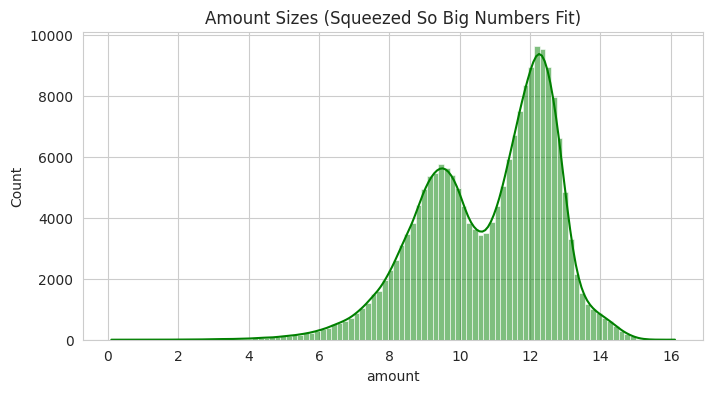

In [ ]:
# Fraud amounts are usually much bigger, so we use a log scale to see it clearly
plt.figure(figsize=(8, 4))
sns.histplot(np.log1p(df['amount']), bins=100, kde=True, color='green')
plt.title("Amount Sizes (Squeezed So Big Numbers Fit)")
plt.show()


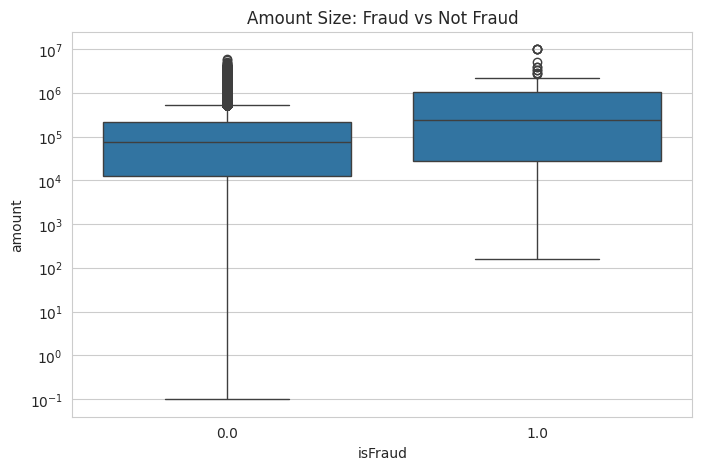

            count           mean           std    min       25%        50%  \
isFraud                                                                      
0.0      199879.0  161065.110569  2.658549e+05    0.1  12404.43   75769.86   
1.0         121.0  935998.846446  1.940947e+06  164.0  27951.26  235512.20   

                75%          max  
isFraud                           
0.0       215227.29   6072832.27  
1.0      1078013.76  10000000.00  


In [ ]:
# Compare amount sizes for fraud vs not-fraud
plt.figure(figsize=(8, 5))
sns.boxplot(x='isFraud', y='amount', data=df)
plt.yscale('log')
plt.title("Amount Size: Fraud vs Not Fraud")
plt.show()

print(df.groupby('isFraud')['amount'].describe())


In [ ]:
# Fraud tip: does the sender's account get COMPLETELY emptied?
emptied_check = (df['amount'] == df['oldbalanceOrg']).astype(int)
print(pd.crosstab(emptied_check, df['isFraud'], normalize='index'))


isFraud       0.0       1.0
row_0                      
0        0.999955  0.000045
1        0.000000  1.000000


**Big discoveries:**
1. Fraud ONLY happens in `TRANSFER` and `CASH_OUT` types. The other types
   (`CASH_IN`, `PAYMENT`, `DEBIT`) never have fraud.
2. Fraud transactions usually move BIGGER amounts of money.
3. Fraud almost always **completely empties** the sender's account.

These clues will help us create new helpful columns in Step 8!


## Step 7: Clean the Data (Summary)

Based on everything we found:
- ✅ No missing pieces left (we removed the 1 bad row earlier)
- ✅ No duplicate rows
- ✅ No impossible negative numbers
- ❌ We will drop `isFlaggedFraud` (doesn't help)
- ❌ We will drop `nameOrig` and `nameDest` (just ID names)
- We keep big/unusual amounts — they are real, not mistakes


## Step 8: Create Helpful New Columns (Feature Engineering)

Now we turn our discoveries from Step 6 into new columns the computer can use.


In [ ]:
# New column: how much money left the sender's account
df['orig_balance_diff'] = df['oldbalanceOrg'] - df['newbalanceOrig']

# New column: how much money the receiver gained
df['dest_balance_diff'] = df['newbalanceDest'] - df['oldbalanceDest']

# New column: 1 if the sender's account was completely emptied, else 0
# (We found this is a HUGE clue for fraud!)
df['orig_emptied'] = (df['amount'] == df['oldbalanceOrg']).astype(int)

# New columns: do the numbers "add up" correctly?
# If money doesn't balance out properly, that's suspicious.
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

df[['orig_balance_diff', 'dest_balance_diff', 'orig_emptied',
    'errorBalanceOrig', 'errorBalanceDest']].head()


,orig_balance_diff,dest_balance_diff,orig_emptied,errorBalanceOrig,errorBalanceDest
0,20693.00,110190.91,0,89497.91,0.00
1,0.00,0.00,0,1958.42,1958.42
2,0.00,0.00,0,23118.62,23118.62
3,-48271.35,-48271.36,0,96542.70,96542.71
4,-179943.82,-179943.81,0,359887.63,359887.62


In [ ]:
# Now let's drop the columns we decided are not useful
df_model = df.drop(columns=['nameOrig', 'nameDest', 'isFlaggedFraud'])
print("Our clean table is ready:", df_model.shape)
df_model.head()


Our clean table is ready: (200000, 13)


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,orig_balance_diff,dest_balance_diff,orig_emptied,errorBalanceOrig,errorBalanceDest
0,19,CASH_OUT,110190.91,20693.00,0.00,235511.20,345702.11,0.0,20693.00,110190.91,0,89497.91,0.00
1,33,PAYMENT,1958.42,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0,1958.42,1958.42
2,17,PAYMENT,23118.62,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0,23118.62,23118.62
3,15,CASH_IN,48271.35,5188138.36,5236409.71,833298.24,785026.88,0.0,-48271.35,-48271.36,0,96542.70,96542.71
4,20,CASH_IN,179943.81,5002402.89,5182346.71,1528965.93,1349022.12,0.0,-179943.82,-179943.81,0,359887.63,359887.62


## Step 9: Separate the Question from the Answer

We need to split our table into two parts:
- **X** = all the clues (everything EXCEPT the answer)
- **y** = the answer (is it fraud or not?)


In [ ]:
X = df_model.drop("isFraud", axis=1)   # X = the clues
y = df_model["isFraud"]                 # y = the answer

print("X (clues) shape:", X.shape)
print("y (answer) shape:", y.shape)
print("\nColumn names in X:", list(X.columns))
print("\nHow many fraud vs not fraud:\n", y.value_counts(normalize=True))

X (clues) shape: (200000, 12)
y (answer) shape: (200000,)

Column names in X: ['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'orig_balance_diff', 'dest_balance_diff', 'orig_emptied', 'errorBalanceOrig', 'errorBalanceDest']

How many fraud vs not fraud:
 isFraud
0.0    0.999395
1.0    0.000605
Name: proportion, dtype: float64


## Step 10: Split into Practice Data and Test Data

We can't let the computer "cheat" by studying the test — that's called
**data leakage**. So we split our data:
- **Training data (80%)** — the computer studies this
- **Test data (20%)** — we hide this until the very end, to see if the
  computer really learned, or just memorized

We use `stratify=y` so both groups have the same tiny amount of fraud —
otherwise the test group might accidentally get zero fraud examples!


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% goes to testing
    stratify=y,          # keep the fraud ratio the same in both groups
    random_state=42       # same split every time we run this
)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)
print("\nFraud ratio in training data:\n", y_train.value_counts(normalize=True))
print("\nFraud ratio in test data:\n", y_test.value_counts(normalize=True))


Training data size: (160000, 12)
Testing data size: (40000, 12)

Fraud ratio in training data:
 isFraud
0.0    0.999394
1.0    0.000606
Name: proportion, dtype: float64

Fraud ratio in test data:
 isFraud
0.0    0.9994
1.0    0.0006
Name: proportion, dtype: float64


## Step 11: Prepare the Data for the Computer

Computers are picky:
- They need NUMBERS, not words. So we turn `type` (like "TRANSFER") into 0s and 1s.
- They work better when all numbers are on a similar scale. So we "scale" them.

We build a little machine (called a **pipeline**) that does this automatically,
the SAME way every time, without mistakes.


In [ ]:
# List which columns are numbers, and which are words/categories
numeric_features = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
                     'oldbalanceDest', 'newbalanceDest', 'orig_balance_diff',
                     'dest_balance_diff', 'orig_emptied', 'errorBalanceOrig',
                     'errorBalanceDest']
categorical_features = ['type']

# For number columns: fill any gaps with the middle value, then scale them evenly
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# For word columns: fill any gaps with the most common word, then turn words into 0s and 1s
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Put both parts together into one "prep machine"
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print("Our prep machine is ready!")


Our prep machine is ready!


## Step 12: Pick Different "Brains" (Models) to Try

There are many ways to teach a computer to guess. We will try several
different "brains" (called models) and see which one guesses best.

Since fraud is SO rare, we tell each model: "Pay extra attention to the
rare fraud examples, don't ignore them!" (`class_weight='balanced'`)


In [ ]:
# Brain 1: Logistic Regression — simple and fast, good starting point
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

# Brain 2: K-Nearest Neighbors — looks at the closest similar examples
knn = KNeighborsClassifier(n_neighbors=5)

# Brain 3: Decision Tree — asks yes/no questions to split the data
dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# Brain 4: Random Forest — many decision trees working together (a "forest")
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)

# Brain 5: Support Vector Machine — draws the best line to separate fraud from not-fraud
svm = SVC(class_weight='balanced', probability=True, random_state=42)

# Brain 6: Naive Bayes — a fast, simple guesser based on probability
nb_model = GaussianNB()

models = {
    "Logistic Regression": log_reg,
    "KNN": knn,
    "Decision Tree": dt,
    "Random Forest": rf,
    "SVM": svm,
    "Naive Bayes": nb_model
}

print("Basic models ready:", list(models.keys()))


Basic models ready: ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'SVM', 'Naive Bayes']


In [ ]:
# More advanced "team" brains — groups of small models working together

# Brain 7: Bagging — trains many small models on random slices of data, then averages them
bagging = BaggingClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Brain 8: AdaBoost — each new small model tries to fix the mistakes of the last one
ada = AdaBoostClassifier(n_estimators=200, random_state=42)

# Brain 9: Gradient Boosting — like AdaBoost, but fixes mistakes in a smarter way
gb = GradientBoostingClassifier(n_estimators=200, random_state=42)

# Brain 10: XGBoost — a super-fast, powerful version of Gradient Boosting
# scale_pos_weight tells it "fraud is rare, pay extra attention to it"
scale_pos_weight = (y_train.value_counts()[0] / y_train.value_counts()[1])
xgb = XGBClassifier(
    n_estimators=200,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

models.update({
    "Bagging": bagging,
    "AdaBoost": ada,
    "Gradient Boosting": gb,
    "XGBoost": xgb
})

print("All models ready:", list(models.keys()))


All models ready: ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'SVM', 'Naive Bayes', 'Bagging', 'AdaBoost', 'Gradient Boosting', 'XGBoost']


## Step 13: Teach Each Model (Training)

Now we actually let each model study the training data. Each model
gets connected to our "prep machine" from Step 11, so the data gets
cleaned automatically every time.


In [ ]:
# We will store each finished, trained model in this box (dictionary)
trained_pipelines = {}

We train each model in its **own separate cell** below. This way, if one
model (like SVM) takes a long time, it won't block you from seeing the others
finish. You can run these cells one at a time, in any order, and skip a slow
one if you want to come back to it later.

`%%time` at the top of each cell shows you exactly how long that model took.


In [ ]:
%%time
# Train: Logistic Regression
name = "Logistic Regression"
pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', models[name])
])
print(f"Teaching {name}...")
pipe.fit(X_train, y_train)   # this is where the model actually LEARNS
trained_pipelines[name] = pipe
print(f"{name} is done!")


Teaching Logistic Regression...
Logistic Regression is done!
CPU times: user 3.31 s, sys: 47.9 ms, total: 3.36 s
Wall time: 2.24 s


In [ ]:
%%time
# Train: KNN
name = "KNN"
pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', models[name])
])
print(f"Teaching {name}...")
pipe.fit(X_train, y_train)   # this is where the model actually LEARNS
trained_pipelines[name] = pipe
print(f"{name} is done!")


Teaching KNN...
KNN is done!
CPU times: user 397 ms, sys: 21.9 ms, total: 419 ms
Wall time: 426 ms


In [ ]:
%%time
# Train: Decision Tree
name = "Decision Tree"
pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', models[name])
])
print(f"Teaching {name}...")
pipe.fit(X_train, y_train)   # this is where the model actually LEARNS
trained_pipelines[name] = pipe
print(f"{name} is done!")


Teaching Decision Tree...
Decision Tree is done!
CPU times: user 2.03 s, sys: 30.8 ms, total: 2.06 s
Wall time: 2.15 s


In [ ]:
%%time
# Train: Random Forest
name = "Random Forest"
pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', models[name])
])
print(f"Teaching {name}...")
pipe.fit(X_train, y_train)   # this is where the model actually LEARNS
trained_pipelines[name] = pipe
print(f"{name} is done!")


Teaching Random Forest...
Random Forest is done!
CPU times: user 1min 3s, sys: 652 ms, total: 1min 4s
Wall time: 56.4 s


In [ ]:
%%time #takes a lot of time
# Train: SVM
name = "SVM"
pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', models[name])
])
print(f"Teaching {name}...")
pipe.fit(X_train, y_train)   # this is where the model actually LEARNS
trained_pipelines[name] = pipe
print(f"{name} is done!")

Teaching SVM...
SVM is done!
CPU times: user 14min 8s, sys: 3.85 s, total: 14min 12s
Wall time: 15min 38s


In [ ]:
%%time
# Train: Naive Bayes
name = "Naive Bayes"
pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', models[name])
])
print(f"Teaching {name}...")
pipe.fit(X_train, y_train)   # this is where the model actually LEARNS
trained_pipelines[name] = pipe
print(f"{name} is done!")


Teaching Naive Bayes...
Naive Bayes is done!
CPU times: user 581 ms, sys: 116 ms, total: 697 ms
Wall time: 704 ms


In [ ]:
%%time
# Train: Bagging
name = "Bagging"
pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', models[name])
])
print(f"Teaching {name}...")
pipe.fit(X_train, y_train)   # this is where the model actually LEARNS
trained_pipelines[name] = pipe
print(f"{name} is done!")


Teaching Bagging...
Bagging is done!
CPU times: user 894 ms, sys: 154 ms, total: 1.05 s
Wall time: 1min 24s


In [ ]:
%%time
# Train: AdaBoost
name = "AdaBoost"
pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', models[name])
])
print(f"Teaching {name}...")
pipe.fit(X_train, y_train)   # this is where the model actually LEARNS
trained_pipelines[name] = pipe
print(f"{name} is done!")


Teaching AdaBoost...
AdaBoost is done!
CPU times: user 1min 12s, sys: 102 ms, total: 1min 13s
Wall time: 1min 17s


In [ ]:
%%time
# Train: Gradient Boosting
name = "Gradient Boosting"
pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', models[name])
])
print(f"Teaching {name}...")
pipe.fit(X_train, y_train)   # this is where the model actually LEARNS
trained_pipelines[name] = pipe
print(f"{name} is done!")


Teaching Gradient Boosting...
Gradient Boosting is done!
CPU times: user 1min 33s, sys: 167 ms, total: 1min 33s
Wall time: 1min 38s


In [ ]:
%%time
# Train: XGBoost
name = "XGBoost"
pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', models[name])
])
print(f"Teaching {name}...")
pipe.fit(X_train, y_train)   # this is where the model actually LEARNS
trained_pipelines[name] = pipe
print(f"{name} is done!")


Teaching XGBoost...
XGBoost is done!
CPU times: user 5.35 s, sys: 73.2 ms, total: 5.42 s
Wall time: 3.37 s


In [ ]:
# Quick check: make sure every model finished and got saved into trained_pipelines
print("Models trained so far:", list(trained_pipelines.keys()))
print("Total:", len(trained_pipelines), "out of", len(models))


Models trained so far: ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'SVM', 'Naive Bayes', 'Bagging', 'AdaBoost', 'Gradient Boosting', 'XGBoost']
Total: 10 out of 10


## Step 14: Test Each Model (Grading Time!)

Now we check how well each model does on the TEST data — data it has
never seen before. This is like a final exam.

We don't just check "how often is it right" (accuracy), because fraud
is so rare that even a lazy model would score high. Instead we check:
- **Precision:** "When it says FRAUD, how often is it actually right?"
- **Recall:** "Out of all the real fraud, how much did it catch?"
- **F1 Score:** a mix of precision and recall


In [ ]:
results = {}   # we will store the scores for each model here

for name, pipe in trained_pipelines.items():
    y_pred = pipe.predict(X_test)   # ask the model to guess on test data

    # Get the model's confidence score, if it can give one
    if hasattr(pipe, "predict_proba"):
        y_proba = pipe.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        roc_auc = np.nan

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc
    }

    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, zero_division=0))



=== Logistic Regression ===
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     39976
         1.0       0.15      0.96      0.26        24

    accuracy                           1.00     40000
   macro avg       0.58      0.98      0.63     40000
weighted avg       1.00      1.00      1.00     40000


=== KNN ===
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     39976
         1.0       1.00      1.00      1.00        24

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000


=== Decision Tree ===
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     39976
         1.0       0.89      1.00      0.94        24

    accuracy                           1.00     40000
   macro avg       0.94      1.00      0.97     40000
weighted 

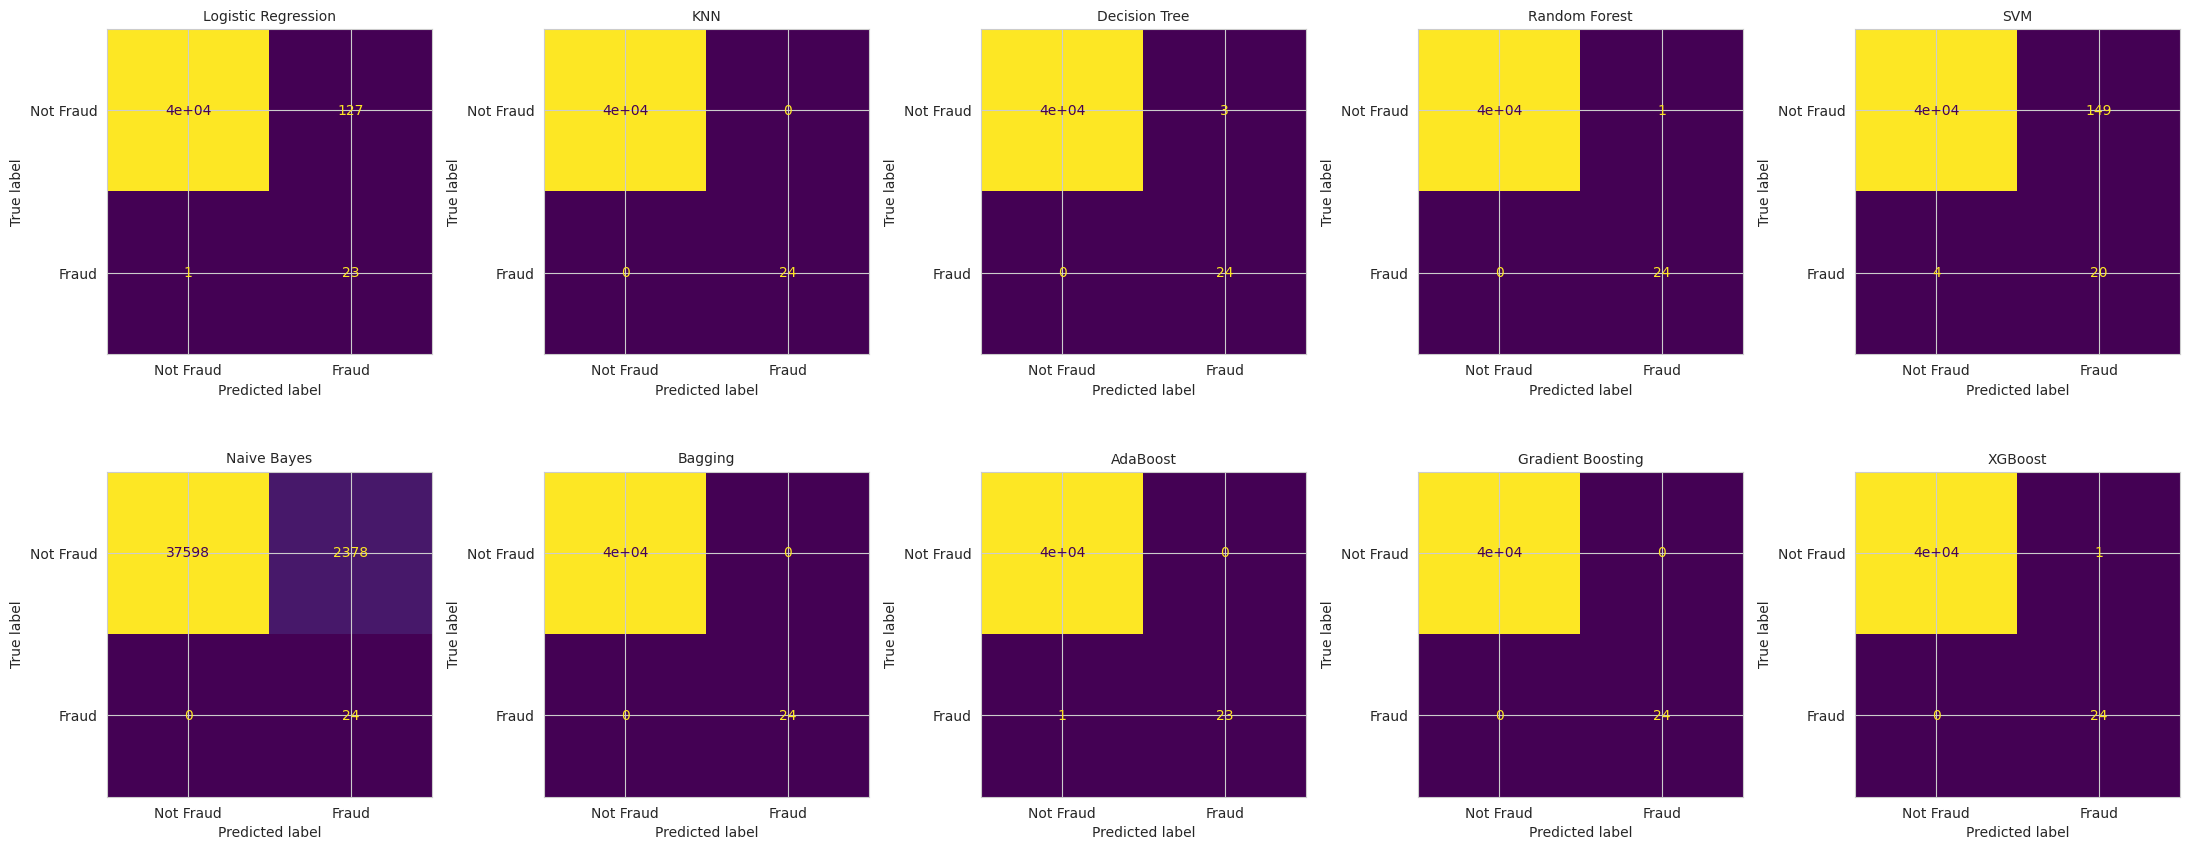

In [ ]:
# A confusion matrix shows exactly what the model got right and wrong
n_models = len(trained_pipelines)
n_cols = 5
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 4.5 * n_rows))
axes = np.array(axes).flatten()

for ax, (name, pipe) in zip(axes, trained_pipelines.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Not Fraud", "Fraud"]).plot(ax=ax, colorbar=False)
    ax.set_title(name, fontsize=10)

for ax in axes[n_models:]:
    ax.axis('off')   # hide any empty boxes

plt.tight_layout()
plt.show()


## Step 15: Compare All Models Side by Side

Let's put all the scores in one table and pick the winners.


In [ ]:
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.sort_values(by="F1 Score", ascending=False)
print(comparison_df.round(4))


                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
KNN                    1.0000     1.0000  1.0000    1.0000   1.0000
Gradient Boosting      1.0000     1.0000  1.0000    1.0000   1.0000
Bagging                1.0000     1.0000  1.0000    1.0000   1.0000
Random Forest          1.0000     0.9600  1.0000    0.9796   1.0000
XGBoost                1.0000     0.9600  1.0000    0.9796   1.0000
AdaBoost               1.0000     1.0000  0.9583    0.9787   1.0000
Decision Tree          0.9999     0.8889  1.0000    0.9412   1.0000
Logistic Regression    0.9968     0.1533  0.9583    0.2644   0.9825
SVM                    0.9962     0.1183  0.8333    0.2073   0.9950
Naive Bayes            0.9406     0.0100  1.0000    0.0198   0.9990


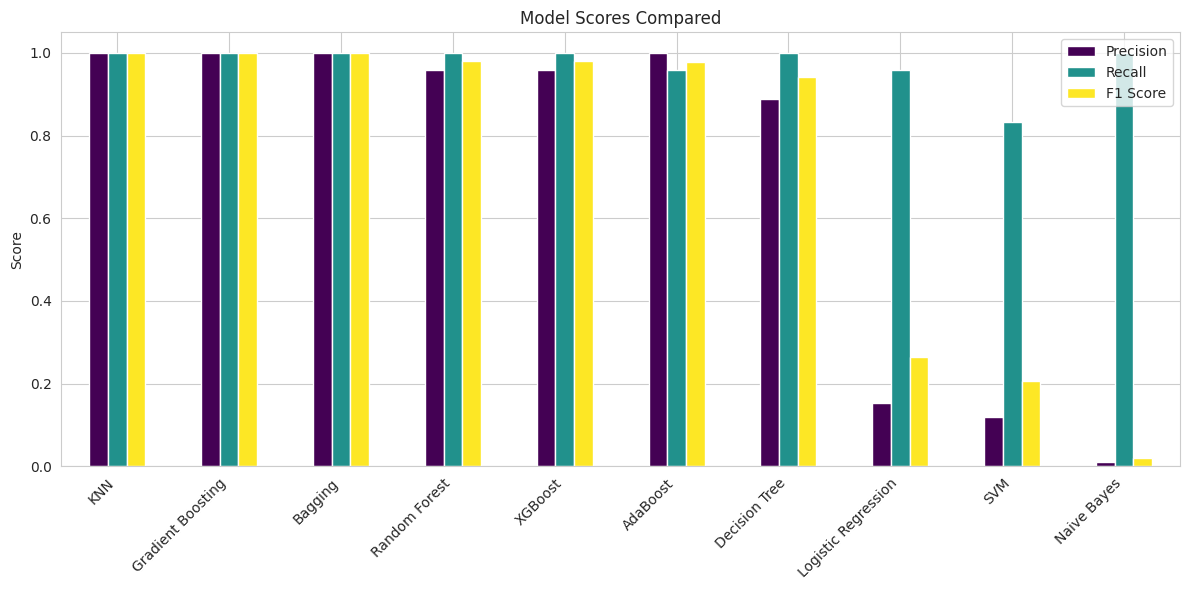

In [ ]:
comparison_df[["Precision", "Recall", "F1 Score"]].plot(
    kind="bar", figsize=(12, 6), colormap="viridis"
)
plt.title("Model Scores Compared")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
best_model_name = comparison_df["F1 Score"].idxmax()
worst_model_name = comparison_df["F1 Score"].idxmin()

print("Best model:", best_model_name)
print(comparison_df.loc[best_model_name])

print("\nWorst model:", worst_model_name)
print(comparison_df.loc[worst_model_name])


Best model: KNN
Accuracy     1.0
Precision    1.0
Recall       1.0
F1 Score     1.0
ROC-AUC      1.0
Name: KNN, dtype: float64

Worst model: Naive Bayes
Accuracy     0.940550
Precision    0.009992
Recall       1.000000
F1 Score     0.019786
ROC-AUC      0.998987
Name: Naive Bayes, dtype: float64


**Important:** we don't just pick the model with the highest score and
stop thinking. A good model should catch real fraud (high recall) without
too many false alarms (good precision too).


## Step 16: Double-Check With Cross-Validation

One test isn't always fair — what if we got lucky or unlucky with our split?
**Cross-validation** tests the model multiple times on different slices of
data, so we get a more trustworthy score.


In [ ]:
# Only double-check our top 3 models (to save time)
top_models = comparison_df.head(3).index.tolist()
print("Double-checking:", top_models)

cv_results = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name in top_models:
    pipe = trained_pipelines[name]
    scores = cross_val_score(pipe, X_train, y_train, cv=skf, scoring='f1', n_jobs=-1)
    cv_results[name] = scores
    print(f"\n{name}")
    print(f"  Scores from each test: {np.round(scores, 4)}")
    print(f"  Average score: {scores.mean():.4f}  |  How much it changes: {scores.std():.4f}")


Double-checking: ['KNN', 'Gradient Boosting', 'Bagging']

KNN
  Scores from each test: [0.9444 0.9444 0.973  0.9744 0.9744]
  Average score: 0.9621  |  How much it changes: 0.0144

Gradient Boosting
  Scores from each test: [0.8947 0.8718 0.973  0.9744 0.9744]
  Average score: 0.9376  |  How much it changes: 0.0450

Bagging
  Scores from each test: [0.9444 0.9444 0.973  0.9744 0.9744]
  Average score: 0.9621  |  How much it changes: 0.0144


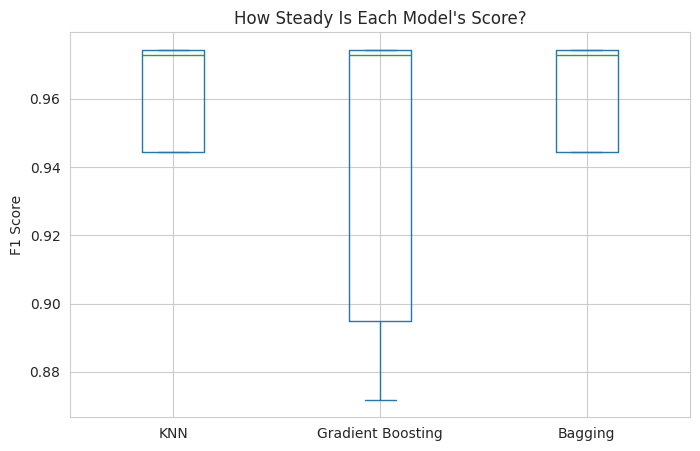

In [ ]:
cv_df = pd.DataFrame(cv_results)
cv_df.plot(kind='box', figsize=(8, 5))
plt.title("How Steady Is Each Model's Score?")
plt.ylabel("F1 Score")
plt.show()


If a model's score barely changes each time we test it, that means it's
**reliable**. If the score jumps around a lot, that model might be less trustworthy.


## Step 17: Fine-Tune the Best Model

Every model has some "settings" (called hyperparameters) we can adjust,
like knobs on a machine. We try a few different knob settings to see which
works best — this is called **tuning**.


In [ ]:
best_cv_model_name = cv_df.mean().idxmax()
print("Fine-tuning:", best_cv_model_name)

base_pipe = trained_pipelines[best_cv_model_name]

# Small lists of settings to try for each type of model
param_grids = {
    "Random Forest": {
        'model__n_estimators': [100, 200],
        'model__max_depth': [None, 10, 20],
        'model__min_samples_split': [2, 5]
    },
    "XGBoost": {
        'model__n_estimators': [100, 200],
        'model__max_depth': [3, 6],
        'model__learning_rate': [0.05, 0.1]
    },
    "Gradient Boosting": {
        'model__n_estimators': [100, 200],
        'model__max_depth': [3, 5],
        'model__learning_rate': [0.05, 0.1]
    },
    "Logistic Regression": {
        'model__C': [0.01, 0.1, 1, 10]
    }
}

param_grid = param_grids.get(best_cv_model_name, {})

if param_grid:
    # GridSearchCV tries every combination of settings and picks the best one
    grid_search = GridSearchCV(
        base_pipe,
        param_grid=param_grid,
        scoring='f1',
        cv=3,
        n_jobs=-1,
        verbose=1
    )
    grid_search.fit(X_train, y_train)

    print("\nBest settings found:", grid_search.best_params_)
    print("Best score:", grid_search.best_score_)

    tuned_model = grid_search.best_estimator_
else:
    print(f"No settings list for {best_cv_model_name} — using it as is.")
    tuned_model = base_pipe


Fine-tuning: KNN
No settings list for KNN — using it as is.


In [ ]:
# Test our fine-tuned model on the test data
y_pred_tuned = tuned_model.predict(X_test)
y_proba_tuned = tuned_model.predict_proba(X_test)[:, 1] if hasattr(tuned_model, "predict_proba") else None

print("=== Fine-Tuned Model Results ===")
print(classification_report(y_test, y_pred_tuned, zero_division=0))
if y_proba_tuned is not None:
    print("ROC-AUC score:", roc_auc_score(y_test, y_proba_tuned))


=== Fine-Tuned Model Results ===
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     39976
         1.0       1.00      1.00      1.00        24

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000

ROC-AUC score: 1.0


## Step 18: Pick Our Final Model

Time to choose our winner! We look at everything: test scores,
cross-validation results, and the fine-tuning results.


In [ ]:
final_comparison = comparison_df.copy()

tuned_row = {
    "Accuracy": accuracy_score(y_test, y_pred_tuned),
    "Precision": precision_score(y_test, y_pred_tuned, zero_division=0),
    "Recall": recall_score(y_test, y_pred_tuned, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred_tuned, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_proba_tuned) if y_proba_tuned is not None else np.nan
}
final_comparison.loc[f"{best_cv_model_name} (Tuned)"] = tuned_row
final_comparison = final_comparison.sort_values(by="F1 Score", ascending=False)

print(final_comparison.round(4))


                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
KNN                    1.0000     1.0000  1.0000    1.0000   1.0000
Gradient Boosting      1.0000     1.0000  1.0000    1.0000   1.0000
Bagging                1.0000     1.0000  1.0000    1.0000   1.0000
KNN (Tuned)            1.0000     1.0000  1.0000    1.0000   1.0000
Random Forest          1.0000     0.9600  1.0000    0.9796   1.0000
XGBoost                1.0000     0.9600  1.0000    0.9796   1.0000
AdaBoost               1.0000     1.0000  0.9583    0.9787   1.0000
Decision Tree          0.9999     0.8889  1.0000    0.9412   1.0000
Logistic Regression    0.9968     0.1533  0.9583    0.2644   0.9825
SVM                    0.9962     0.1183  0.8333    0.2073   0.9950
Naive Bayes            0.9406     0.0100  1.0000    0.0198   0.9990


In [ ]:
# This is our winner!
final_model = tuned_model
final_model_name = f"{best_cv_model_name} (Tuned)"

print("Our final chosen model is:", final_model_name)
print("\nIts test scores:")
print(final_comparison.loc[final_model_name])


Our final chosen model is: KNN (Tuned)

Its test scores:
Accuracy     1.0
Precision    1.0
Recall       1.0
F1 Score     1.0
ROC-AUC      1.0
Name: KNN (Tuned), dtype: float64


## Step 19: Make Sure the Final Model Works on Raw Data

Our final model should be able to take RAW, un-prepared data and still
work correctly — because it has our "prep machine" built right inside it!


In [ ]:
print(final_model)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['step', 'amount',
                                                   'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest',
                                                   'orig_balance_diff',
                                                   'dest_balance_diff',
                                                   'orig_emptied',
          

In [ ]:
# Let's test it on 5 real example rows, just like a real app would send it
sample_raw = X_test.iloc[:5]
sample_preds = final_model.predict(sample_raw)
sample_probs = final_model.predict_proba(sample_raw)[:, 1] if hasattr(final_model, "predict_proba") else None

print("Predictions:", sample_preds)
if sample_probs is not None:
    print("Confidence it's fraud:", np.round(sample_probs, 4))


Predictions: [0. 0. 0. 0. 0.]
Confidence it's fraud: [0. 0. 0. 0. 0.]


## Step 20: Save Our Model

We save our trained model into a file called `model.pkl`, so we don't
have to retrain it every time — we can just load the file whenever we need it.


In [ ]:
import joblib

joblib.dump(final_model, "model.pkl")
print("Model saved! You will see a file called model.pkl now.")


Model saved! You will see a file called model.pkl now.


## Step 21: Load It Back and Test It Again

Let's make sure the saved file actually works by loading it fresh and
trying it on a made-up example transaction.


In [ ]:
# Load the model back from the file
loaded_model = joblib.load("model.pkl")
print("Model loaded successfully!")


Model loaded successfully!


In [ ]:
# Make up a fake transaction to test: a big transfer that empties the account
# (this is exactly the pattern we learned is usually fraud!)
new_sample = pd.DataFrame([{
    "step": 10,
    "type": "TRANSFER",
    "amount": 250000.0,
    "oldbalanceOrg": 250000.0,
    "newbalanceOrig": 0.0,
    "oldbalanceDest": 0.0,
    "newbalanceDest": 250000.0,
    "orig_balance_diff": 250000.0,
    "dest_balance_diff": 250000.0,
    "orig_emptied": 1,
    "errorBalanceOrig": 0.0,
    "errorBalanceDest": 0.0
}])

prediction = loaded_model.predict(new_sample)
probability = loaded_model.predict_proba(new_sample)[:, 1]

print("Prediction (0 = Not Fraud, 1 = Fraud):", prediction[0])
print(f"Confidence it's fraud: {probability[0]:.2%}")


Prediction (0 = Not Fraud, 1 = Fraud): 1.0
Confidence it's fraud: 100.00%


### ✅ We're Done With the Machine Learning Part!

We now have:
- A clean dataset
- Useful new columns based on real fraud patterns
- A tested, tuned, saved model that can guess fraud from raw data

**Next:** we build a simple website (Streamlit app) so anyone can type in
a transaction and get an instant answer — see `app.py`.
